<a href="https://colab.research.google.com/github/vivek-rd/deep-rec-sys-amazon-reviews/blob/dev/HSACN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
!pip install datasets

In [ ]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from dataclasses import dataclass
from datasets import load_dataset
import gensim.downloader as downloader

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
#this is basically users dataset coz only users have the associated reviews, not the items. So we don't need items data at all if only going with reviews.

dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_review_Appliances", split= 'full', trust_remote_code=True)
dataset[0]

{'rating': 5.0,
 'title': 'Work great',
 'text': 'work great. use a new one every month',
 'images': [],
 'asin': 'B01N0TQ0OH',
 'parent_asin': 'B01N0TQ0OH',
 'user_id': 'AGKHLEW2SOWHNMFQIJGBECAF7INQ',
 'timestamp': 1519317108692,
 'helpful_vote': 0,
 'verified_purchase': True}

In [ ]:
sample_dataset= dataset.take(1000)

# Analysis

In [ ]:
df= sample_dataset.to_pandas()
df.head()

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Work great,work great. use a new one every month,[],B01N0TQ0OH,B01N0TQ0OH,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1519317108692,0,True
1,5.0,excellent product,Little on the thin side,[],B07DD2DMXB,B07DD37QPZ,AHWWLSPCJMALVHDDVSUGICL6RUCA,1664746863446,0,True
2,5.0,Happy customer!,"Quick delivery, fixed the issue!",[],B082W3Z9YK,B082W3Z9YK,AHZIJGKEWRTAEOZ673G5B3SNXEGQ,1607225435363,0,True
3,5.0,Amazing value,I wasn't sure whether these were worth it or n...,[],B078W2BJY8,B078W2BJY8,AFGUPTDFAWOHHL4LZDV27ERDNOYQ,1534104184306,0,True
4,5.0,Dryer parts,Easy to install got the product expected to re...,[],B08C9LPCQV,B08C9LPCQV,AELFJFAXQERUSMTXJQ6SYFFRDWMA,1620176603754,0,True


In [ ]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df['sentence_count'] = df['text'].apply(lambda x: len(sent_tokenize(x)))

print("Word Count Statistics:")
print(df['word_count'].describe())

print("\nSentence Count Statistics:")
print(df['sentence_count'].describe())

Word Count Statistics:
count    2.128605e+06
mean     3.149559e+01
std      5.160581e+01
min      0.000000e+00
25%      7.000000e+00
50%      1.600000e+01
75%      3.700000e+01
max      3.636000e+03
Name: word_count, dtype: float64

Sentence Count Statistics:
count    2.128605e+06
mean     2.619201e+00
std      2.709329e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      2.050000e+02
Name: sentence_count, dtype: float64


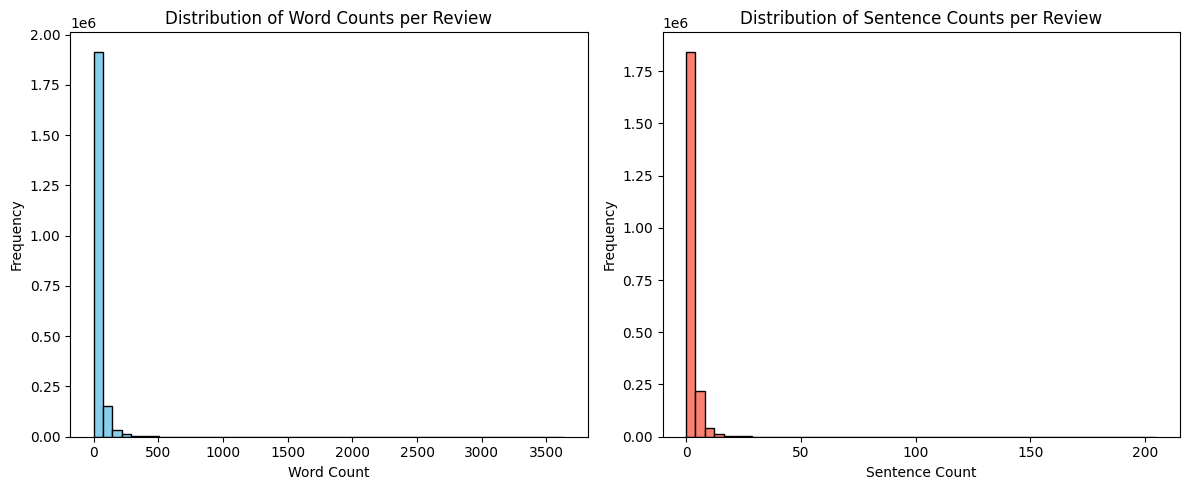

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Word Counts per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(df['sentence_count'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Sentence Counts per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Most of the Word Count is concentrated between 0 to 500 and Sentence Count between 0 to 30 atmost, so zooming in on that.

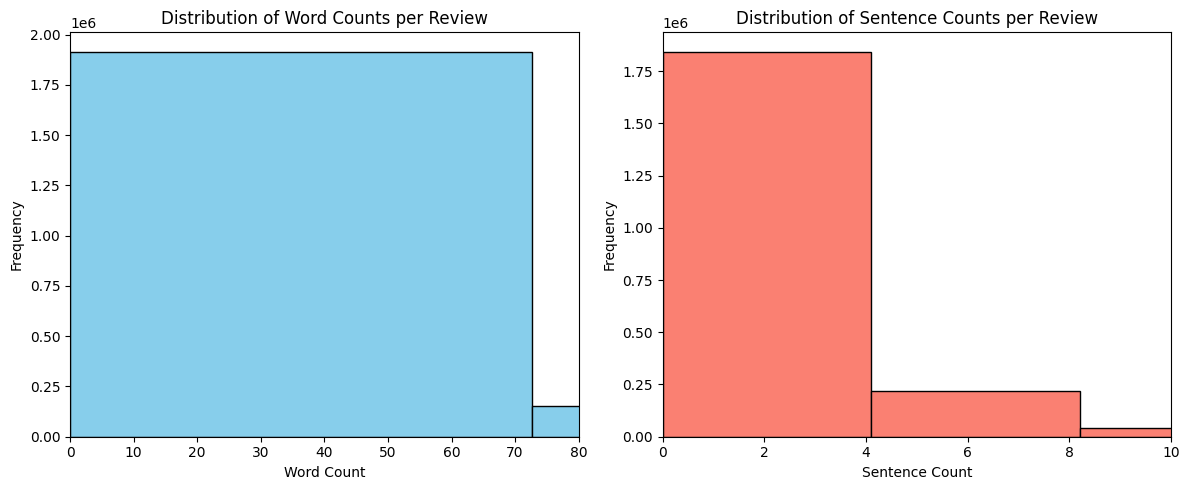

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['word_count'], bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution of Word Counts per Review")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.xlim(0, 80) #plt.xlim(0, 500)

plt.subplot(1, 2, 2)
plt.hist(df['sentence_count'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Sentence Counts per Review")
plt.xlabel("Sentence Count")
plt.ylabel("Frequency")
plt.xlim(0, 10) #plt.xlim(0, 30)

plt.tight_layout()
plt.show()

So it's safe to assume we would have 100 words per review, and 7 sentences per review (after changing the limits, the number changed to 70, 4 on further experiments). The catch is, we want words per sentences for the sentence encoder and not words per review. It would be time consuming to calculate that so we can settle for approximating by (words_per_review / sentence_per_review) to get words_per_sentence.

In [ ]:
avg_words = df['word_count'].mean()
avg_sentences = df['sentence_count'].mean()

avg_words_per_sentence = avg_words / avg_sentences

print("Average words per review:", avg_words)
print("Average sentences per review:", avg_sentences)
print("Estimated average words per sentence:", avg_words_per_sentence)

Average words per review: 31.495586076326983
Average sentences per review: 2.619200838107587
Estimated average words per sentence: 12.024883933330988


In [ ]:
# Reviews per user
reviews_per_user = df.groupby('user_id').size().reset_index(name='review_count')
print(reviews_per_user.describe())

print("\n")

# Reviews per item
reviews_per_item = df.groupby('parent_asin').size().reset_index(name='review_count')
print(reviews_per_item.describe())

print("\n")

reviews_90 = reviews_per_user['review_count'].quantile(0.90)
print("90% of the users have at most", reviews_90, "reviews.")

reviews_90 = reviews_per_item['review_count'].quantile(0.90)
print("90% of the items have at most", reviews_90, "reviews.")

       review_count
count  1.755732e+06
mean   1.212375e+00
std    6.759095e-01
min    1.000000e+00
25%    1.000000e+00
50%    1.000000e+00
75%    1.000000e+00
max    1.110000e+02


       review_count
count  94319.000000
mean      22.568146
std      146.509600
min        1.000000
25%        1.000000
50%        3.000000
75%        9.000000
max    12027.000000


90% of the users have at most 2.0 reviews.
90% of the items have at most 34.0 reviews.


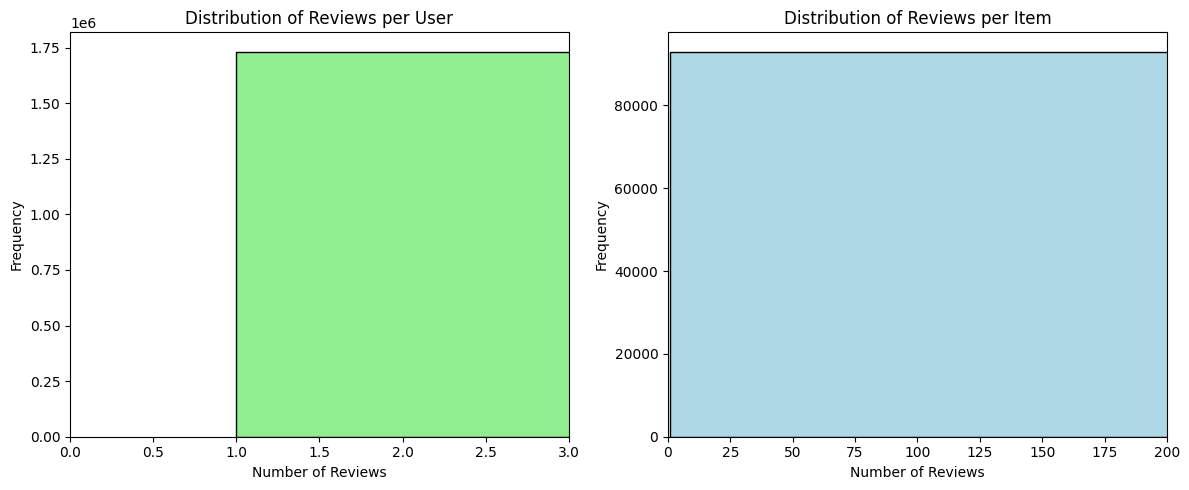

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(reviews_per_user['review_count'], bins=50, color='lightgreen', edgecolor='black')
plt.title("Distribution of Reviews per User")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.xlim(0, 3)

plt.subplot(1, 2, 2)
plt.hist(reviews_per_item['review_count'], bins=50, color='lightblue', edgecolor='black')
plt.title("Distribution of Reviews per Item")
plt.xlabel("Number of Reviews")
plt.ylabel("Frequency")
plt.xlim(0, 200)

plt.tight_layout()
plt.show()

After a bit of experimenting, found out that we could take 3 reviews per user and 200 reviews per item.

This is with the graph, it was misleading. 90% of items have 34 reviews.

In [ ]:
item_reviews = df.groupby('parent_asin')['text'].apply(lambda x: 'rrr'.join(x)).reset_index()
user_reviews= df.groupby('user_id')['text'].apply(lambda x: 'rrr'.join(x)).reset_index()

# Preprocessing into embeddings

In [ ]:
def split_data(df):
    train, temp = train_test_split(df, test_size=0.2, random_state=42)
    val, test = train_test_split(temp, test_size=0.5, random_state=42)
    return train, val, test

train, val, test = split_data(df)

In [ ]:
data = {
    'user_id': ['u1', 'u1', 'u1', 'u2', 'u2'],
    'parent_asin': ['i1', 'i2', 'i3', 'i1', 'i3'],
    'text': ['r1', 'r2', 'r3', 'r4', 'r5']
}

df = pd.DataFrame(data)

In [ ]:
embed_model = downloader.load('word2vec-google-news-300')
# To save the model for later use: model.save('google_news_embeddings.model')

## Slow preprocessing

In [ ]:
user_reviews = df.groupby('user_id')['text'].apply(lambda x: 'rrr'.join(x)).reset_index()
item_reviews = df.groupby('parent_asin')['text'].apply(lambda x: 'rrr'.join(x)).reset_index()


def exclude_review(df, user, item):
    user_reviews = df[df['user_id'] == user]
    item_reviews = df[df['parent_asin'] == item]

    # Excluding the current (user, item) review to prevent data leakage
    user_excluded = 'rrr'.join(user_reviews[user_reviews['parent_asin'] != item]['text'])
    item_excluded = 'rrr'.join(item_reviews[item_reviews['user_id'] != user]['text'])

    return user_excluded, item_excluded


train_df = df.copy()
train_df[['user_excluded', 'item_excluded']] = train_df.apply(
    lambda row: exclude_review(df, row['user_id'], row['parent_asin']), axis=1, result_type='expand'
)


In [ ]:
def process_text(text, words_per_sentence, sentences_per_review, reviews_per_entity):

    raw_reviews = text.split("rrr")

    reviews = []
    for review in raw_reviews[:reviews_per_entity]:
        sentences = nltk.sent_tokenize(review)
        tokenized_sentences = []

        for sentence in sentences[:sentences_per_review]:
            words = nltk.word_tokenize(sentence)
            #words = sentence.split()

            words = words[:words_per_sentence] + ['<PAD>'] * max(0, words_per_sentence - len(words))
            tokenized_sentences.append(words)

        while len(tokenized_sentences) < sentences_per_review:  # sentences < sentences_per_review, pad with empty sentences (list of PAD tokens)
            tokenized_sentences.append(['<PAD>'] * words_per_sentence)
        reviews.append(tokenized_sentences)

    while len(reviews) < reviews_per_entity: # reviews < reviews_per_entity, pad with empty reviews.
        reviews.append([['<PAD>'] * words_per_sentence for _ in range(sentences_per_review)])
    return reviews

def text_to_embedding(tokenized_text, embedding_dict, embedding_dim):
    reviews_emb = []
    for review in tokenized_text:
        sentences_emb = []
        for sentence in review:
            sentence_emb = []
            for word in sentence:
                if word in embedding_dict:
                    emb = embedding_dict[word]
                else:
                    emb = np.zeros(embedding_dim)
                #emb = embedding_dict.get(word, np.zeros(embedding_dim))
                sentence_emb.append(emb)
            sentences_emb.append(sentence_emb)
        reviews_emb.append(sentences_emb)
    return torch.tensor(reviews_emb, dtype=torch.float)  # shape: (num_reviews, num_sentences, num_words, embedding_dim)

In [ ]:
words_per_sentence = 12
sentences_per_review = 4
user_reviews_per_entity = 3
item_reviews_per_entity = 35
embedding_dim = 300

In [ ]:
tokenized_item = process_text(fake_review_text, words_per_sentence, sentences_per_review, item_reviews_per_entity)
item_tensor = text_to_embedding(tokenized_item, fake_embedding_dict, embedding_dim)
# Now, item_tensor.shape should be (5, 5, 10, 50)

In [ ]:
tokenized_item

[[['The',
   'movie',
   'was',
   'absolutely',
   'amazing!',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['The',
   'characters',
   'were',
   'well-developed,',
   'and',
   'the',
   'plot',
   'was',
   'engaging.',
   '<PAD>'],
  ['I',
   'highly',
   'recommend',
   'watching',
   'it.',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>']],
 [['<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>',
   '<PAD>'],
  ['<PAD>',
   '

In [ ]:
print(item_tensor)

In [ ]:
user_reviews['tokenized'] = user_reviews['text'].apply(
    lambda t: process_text(t, words_per_sentence, sentences_per_review, user_reviews_per_entity)
)
user_reviews['user_embedding'] = user_reviews['tokenized'].apply(
    lambda tokens: text_to_embedding(tokens, embed_model, embedding_dim)
)


item_reviews['tokenized'] = item_reviews['text'].apply(
    lambda t: process_text(t, words_per_sentence, sentences_per_review, item_reviews_per_entity)
)
item_reviews['item_embedding'] = item_reviews['tokenized'].apply(
    lambda tokens: text_to_embedding(tokens, embed_model, embedding_dim)
)

#till adding tokenized for items, it was 16s, while doing embedding, it last upto 1m 19s

<ipython-input-20-11a416361352>:40: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  return torch.tensor(reviews_emb, dtype=torch.float)  # shape: (num_reviews, num_sentences, num_words, embedding_dim)


In [ ]:
user_emb_df = user_reviews[['user_id', 'user_embedding']]
item_emb_df = item_reviews[['parent_asin', 'item_embedding']]

df_reduced = df[['user_id', 'parent_asin', 'text', 'rating']]

merged = df_reduced.merge(user_emb_df, on='user_id', how='left')
merged = merged.merge(item_emb_df, on='parent_asin', how='left')

## Fast Pre-processing

In [ ]:
%%time

#vivek's code

# took 19.6 seconds for 105K rows

words_per_sentence = 12
sentences_per_review = 4
embedding_dim = 300
user_reviews_per_entity = 3
item_reviews_per_entity = 35

def process_text(text, sentences_per_review, words_per_sentence, embedding_dim, embed_dict):

    output = np.zeros((sentences_per_review, words_per_sentence, embedding_dim))
    sentences = nltk.sent_tokenize(str(text))

    for i, sentence in enumerate(sentences[0:sentences_per_review]):
        words = nltk.word_tokenize(sentence)
        for j, word in enumerate(words[0:words_per_sentence]):
            if word in embed_dict:
                output[i, j] = embed_dict[word]

    return torch.tensor(output)

df['embedding'] = df['text'].apply(lambda x: process_text(x, sentences_per_review, words_per_sentence, embedding_dim, embed_model))

In [ ]:
def exclude_review_embeddings(df, user, item):
    user_reviews = df[df['user_id'] == user]
    item_reviews = df[df['parent_asin'] == item]

    # Exclude the current (user, item) review
    user_excluded = torch.stack(user_reviews[user_reviews['parent_asin'] != item]['embedding'].tolist())
    item_excluded = torch.stack(item_reviews[item_reviews['user_id'] != user]['embedding'].tolist())

    return user_excluded, item_excluded

train_df[['user_excluded', 'item_excluded']] = train_df.apply(
    lambda row: exclude_review(df, row['user_id'], row['parent_asin']), axis=1, result_type='expand'
)

# Model Classes/Parts

**1. Sequence Encoding Module**


This module takes a sequence of embeddings `{x₁, ..., xₜ}` (each `xᵢ` in `ℝ^{d}`) and outputs contextual representations `{z₁, ..., zₜ}` (each `zᵢ` in `ℝ^{dₖ}`).

What it does:
  - **Local convolution over a sliding window** (n-gram extraction): Basically convolution as the paper calls it—don’t get too technical, we’re just sliding over some window and extracting n-grams.
  - **Multihead self-attention** with relative position embeddings: For those global dependencies that we just can’t live without.
  - **A one-layer feed-forward network with ReLU**: You know, the usual ReLU magic after attention.

Note: In the paper, the convolution “concatenates” n embeddings and then multiplies them by weights `WQ, WK, WV` of shape `(dₖ, n*d)`. My brilliant self figured out that this could actually be done with `nn.Conv1d`. Don’t ask me how, I still don’t know how I pulled it off.


In [ ]:
class SequenceEncodingModule(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_heads, max_seq_len):
        """
        Args:
            input_dim: Dimension of input embeddings, d.
            hidden_dim: Hidden dimension of this module, d_k.
            kernel_size: n (width for n-gram features)
            num_heads: Number of attention heads, H. (d_h = hidden_dim / num_heads)
            max_seq_len: Maximum sequence length (used for relative positional embeddings)
        """
        super(SequenceEncodingModule, self).__init__()
        self.input_dim = input_dim       # d
        self.hidden_dim = hidden_dim     # d_k
        self.kernel_size = kernel_size   # n
        self.num_heads = num_heads
        self.d_h = hidden_dim // num_heads  # subspace dimension d_h (assume hidden_dim divisible by num_heads)
        self.max_seq_len = max_seq_len

        # Convolution layers for computing q, k, v.
        # Using Conv1d with kernel_size = n and padding = floor((n-1)/2) gives a sliding window effect.
        # But we skip padding since our sequences are fixed-length. Simpler = better.
        padding = kernel_size // 2  # Works when n is odd.
        self.conv_q = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)
        self.conv_k = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)
        self.conv_v = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim, kernel_size=kernel_size, padding=padding)

        # Feed-forward layer after attention (W_f, b_f)
        self.ff = nn.Linear(hidden_dim, hidden_dim)

        # Relative positional embeddings for keys and values.
        # Assumes a fixed maximum sequence length, obviously. For each (i, j) pair, we learn a vector in R^(d_h). Fancy.
        self.p_K = nn.Parameter(torch.randn(max_seq_len, max_seq_len, self.d_h))
        self.p_V = nn.Parameter(torch.randn(max_seq_len, max_seq_len, self.d_h))

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch, seq_len, input_dim)
        Returns:
            z: Tensor of shape (batch, seq_len, hidden_dim) after encoding.
        """
        batch, t, _ = x.size()

        # First, apply convolution. Conv1d expects (batch, channels, seq_len), so let’s flip some axes.
        x_conv = x.transpose(1, 2)       # (batch, input_dim, t)
        q = F.relu(self.conv_q(x_conv))  # (batch, hidden_dim, t)
        k = F.relu(self.conv_k(x_conv))
        v = F.relu(self.conv_v(x_conv))

        # Back to (batch, t, hidden_dim)
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Split each into H heads: reshape from (batch, t, hidden_dim) to (batch, H, t, d_h)
        q = q.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)  # (batch, num_heads, t, d_h)
        k = k.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)
        v = v.view(batch, t, self.num_heads, self.d_h).transpose(1, 2)

        # ---------------------------
        # Multihead Self-Attention with Relative Position Embeddings
        # ---------------------------

        # Standard attention scores: for each head h, for positions i and j: score_std[i,j] = <q_i^h, k_j^h>
        scores_std = torch.matmul(q, k.transpose(-2, -1))  # (batch, num_heads, t, t)

        # Relative position term for keys: p_k has shape (max_seq_len, max_seq_len, d_h). Slice to current sequence length.
        p_K = self.p_K[:t, :t, :]  # (t, t, d_h) PyTorch is fucking weird.

        # Compute extra scores: for each head h, each position i and j, e_relative[i,j] = <q_i^h, p_K[i,j]>
        # We do this by broadcasting: (batch, num_heads, t, 1, d_h) * (1, 1, t, t, d_h) -> sum over d_h.
        e_relative = (q.unsqueeze(3) * p_K.unsqueeze(0).unsqueeze(0)).sum(-1)  # (batch, num_heads, t, t)

        # Total attention scores(scaled)
        scores = (scores_std + e_relative) / math.sqrt(self.d_h)  # (batch, num_heads, t, t)
        attn = F.softmax(scores, dim=-1)                          # attention weights a_ij^h

        # Compute attention output.
        # First, weighted sum for v:
        z_v = torch.matmul(attn, v)                                             # (batch, num_heads, t, d_h)
        p_V = self.p_V[:t, :t, :]                                               # Now adding relative contribution from values using p_v | shape: (t, t, d_h)
        z_p = (attn.unsqueeze(-1) * p_V.unsqueeze(0).unsqueeze(0)).sum(dim=-2)  # For each i, add: sum_j a_{ij}^h * p_V^{ij} | shape: (batch, num_heads, t, d_h)
        z = z_v + z_p  # (batch, num_heads, t, d_h)

        z = z.transpose(1, 2).contiguous().view(batch, t, self.hidden_dim) # Concatenating all heads: from (batch, num_heads, t, d_h) to (batch, t, hidden_dim)
        z = F.relu(self.ff(z))                                             # feed-forward layer with ReLU (W_f and b_f in Equation (7) in paper) | shape: (batch, t, hidden_dim)

        return z

**2. Sequence Aggregating Module**


This module takes the output `{z₁, ..., zₜ}` (each in `ℝ^{dₖ}`)
and aggregates them into one vector `l` (in `ℝ^{dₖ}`) via an attention network.
For each element:
   `scoreᵢ = hᵀ ReLU(Wₚ zᵢ + bₚ)`
and then `l = Σᵢ (softmax(scoreᵢ) * zᵢ)`

Here, `Wₚ ∈ ℝ^{dₚ×dₖ}`, `bₚ ∈ ℝ^{dₚ}`, `h ∈ ℝ^{dₚ}` with `dₚ = dₖ/2`.


In [ ]:
class SequenceAggregatingModule(nn.Module):
    def __init__(self, hidden_dim):
        """
        Args: hidden_dim: d_k (the same hidden dimension used in encoding)
        """
        super(SequenceAggregatingModule, self).__init__()
        self.hidden_dim = hidden_dim
        self.d_p = hidden_dim // 2                   # per paper, d_p = d_k/2
        self.W_p = nn.Linear(hidden_dim, self.d_p)   # This covers multiplication by W_p and addition of b_p.
        self.h = nn.Parameter(torch.randn(self.d_p)) # h is a learnable vector in R^(d_p)

    def forward(self, z):
        """
        Args:
            z: Tensor of shape (batch, seq_len, hidden_dim)
        Returns:
            l: Aggregated vector of shape (batch, hidden_dim)
        """

        r = F.relu(self.W_p(z))                       # intermediate representation: r_i = ReLU(W_p z_i + b_p) | shape: (batch, seq_len, d_p)
        scores = torch.matmul(r, self.h)              # importance scores: score_i = h^T r_i | shape: (batch, seq_len)
        attn = F.softmax(scores, dim=-1)              # Normalizing to get attention weights a_i | shape: (batch, seq_len)
        l = torch.sum(z * attn.unsqueeze(-1), dim=1)  # Weighted sum of z_i's | (batch, hidden_dim)

        return l

**3. Combined Sequence Encoder**

This module combines the above two modules. It can be used to encode a sentence from words, a review from sentences, or even a user/item from reviews. So, we gonna use as a base for the next class.

In [ ]:
class SequenceEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_heads, max_seq_len):
        """
        Args:
            input_dim: Dimension of input embeddings.
            hidden_dim: Hidden dimension d_k.
            kernel_size: n-gram width.
            num_heads: Number of attention heads.
            max_seq_len: Maximum sequence length.
        """
        super(SequenceEncoder, self).__init__()
        self.encoding_module = SequenceEncodingModule(input_dim, hidden_dim, kernel_size, num_heads, max_seq_len)
        self.aggregating_module = SequenceAggregatingModule(hidden_dim)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (batch, seq_len, input_dim)
        Returns:
            l: Aggregated representation of shape (batch, hidden_dim)
        """
        z = self.encoding_module(x)    # (batch, seq_len, hidden_dim)
        l = self.aggregating_module(z)  # (batch, hidden_dim)
        return l

**4. Hierarchical Encoder**

We use the previously defined SentenceEncoder to pass different arguments and process the three levels.

- For each sentence (words → sentence representation)
- For each review (sentences → review representation)
- For the user/item overall (reviews → final representation)


In [ ]:
class HierarchicalEncoder(nn.Module):
    def __init__(self, word_embedding_dim, hidden_dim, kernel_size, num_heads, words_per_sentence, sentences_per_review, reviews_per_entity):

        super(HierarchicalEncoder, self).__init__()

        self.sentence_encoder = SequenceEncoder(word_embedding_dim, hidden_dim, kernel_size, num_heads, words_per_sentence)
        self.review_encoder = SequenceEncoder(hidden_dim, hidden_dim, kernel_size, num_heads, sentences_per_review)
        self.final_encoder = SequenceEncoder(hidden_dim, hidden_dim, kernel_size, num_heads, reviews_per_entity)

    def forward(self, x):
        """
        Args:
            x: Tensor of shape (B, R, S, W, E) where:
                B: batch size,
                R: reviews per entity,
                S: sentences per review,
                W: words per sentence,
                E: word embedding dimension.
        Returns:
            final_rep: Tensor of shape (B, hidden_dim)
        """
        B, R, S, W, E = x.size()

        x_sentences = x.view(B * R * S, W, E)              # Flatten reviews and sentences into one dimension: (B * R * S, W, E)
        sentence_reps = self.sentence_encoder(x_sentences) # Processing all sentences at once: each sentence → a sentence representation (B * R * S, hidden_dim)
        sentence_reps = sentence_reps.view(B, R, S, -1)    # Reshape back to (B, R, S, hidden_dim)

        x_reviews = sentence_reps.view(B * R, S, -1)       # For each review, we have S sentence representations. Flatten reviews: (B * R, S, hidden_dim)
        review_reps = self.review_encoder(x_reviews)       # Processing all reviews: (B * R, hidden_dim)
        review_reps = review_reps.view(B, R, -1)           # Reshape back to (B, R, hidden_dim)

        final_rep = self.final_encoder(review_reps)        # Processing the sequence of reviews for each entity: (B, R, hidden_dim) → (B, hidden_dim)
        return final_rep

**5. Rating Predictor**

A simple rating predictor that concatenates user and item representations for now. If this works, I can improve terms of complexity.

In [ ]:
class RatingPredictor(nn.Module):
    def __init__(self, rep_dim, hidden_size=64):
        super(RatingPredictor, self).__init__()
        self.fc1 = nn.Linear(rep_dim * 2, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)  # Predicts a single rating value

    def forward(self, user_rep, item_rep):
        x = torch.cat([user_rep, item_rep], dim=-1)
        x = torch.relu(self.fc1(x))
        rating = self.fc2(x)
        return rating

# Complete Recommendation Model
The complete recommendation model using a two-tower architecture.

In [ ]:
#
class RecommendationModel(nn.Module):
    def __init__(self, word_embedding_dim, hidden_dim, kernel_size, num_heads, words_per_sentence,
                 sentences_per_review, user_reviews_per_entity, item_reviews_per_entity):
        super(RecommendationModel, self).__init__()
        self.user_encoder = HierarchicalEncoder(word_embedding_dim, hidden_dim, kernel_size, num_heads,
                                                  words_per_sentence, sentences_per_review, user_reviews_per_entity)
        self.item_encoder = HierarchicalEncoder(word_embedding_dim, hidden_dim, kernel_size, num_heads,
                                                  words_per_sentence, sentences_per_review, item_reviews_per_entity)
        self.rating_predictor = RatingPredictor(hidden_dim)

    def forward(self, user_input, item_input):
        # user_input and item_input are hierarchical tensors.
        user_rep = self.user_encoder(user_input)  # (batch, hidden_dim)
        item_rep = self.item_encoder(item_input)  # (batch, hidden_dim)
        rating = self.rating_predictor(user_rep, item_rep)  # (batch, 1)
        return rating

# Training

**1. Dataset & DataLoader**

Merged DataFrame (merged) contains the columns:
- 'user_embedding': torch.Tensor of shape (reviews_per_entity sentences_per_review, words_per_sentence, embedding_dim)
- 'item_embedding': same shape
- 'rating': numerical target

Note: user_id and parent_asin have already been used for grouping and are not fed into the model, so we're not preprocesing them.

In [ ]:
class RecSysDataset(Dataset):

  """
  The input dataframe should be the original dataframe, along with an additional column where we have the preprocessed embeddings matrix
  of (sentences in review, words in a sentence, emb dimension) size.
  """

  def __init__(self, df, user_reviews_per_entity, item_reviews_per_entity):
    self.df = df
    self.user_reviews_per_entity = user_reviews_per_entity
    self.item_reviews_per_entity = item_reviews_per_entity

    # Pre-grouping user and item reviews instead of fetching it everytime in getitem
    self.user_reviews = defaultdict(list)
    self.item_reviews = defaultdict(list)

    for _, row in df.iterrows():
        self.user_reviews[row['user_id']].append(row['embedding'])
        self.item_reviews[row['parent_asin']].append(row['embedding'])

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]
    user = row['user_id']
    item = row['parent_asin']
    current_review = row['embedding']
    rating = row['rating']

    """
    if the embeddings weren't pre-grouped, we should do something like this:
    user_embs = self.df[self.df['user_id'] == user]['embedding'].tolist()
    item_embs = self.df[self.df['parent_asin'] == item]['embedding'].tolist()

    this means, everytime a batch is loaded, this group by will happen, that is an overhead.
    """
    # Pre-grouped embeddings
    user_embs = [emb for emb in self.user_reviews[user] if not torch.equal(emb, current_review)]
    item_embs = [emb for emb in self.item_reviews[item] if not torch.equal(emb, current_review)]

    user_embs = user_embs[:self.user_reviews_per_entity] + [torch.zeros_like(current_review)] * (self.user_reviews_per_entity - len(user_embs))
    item_embs = item_embs[:self.item_reviews_per_entity] + [torch.zeros_like(current_review)] * (self.item_reviews_per_entity - len(item_embs))

    user_embs = torch.stack(user_embs)
    item_embs = torch.stack(item_embs)

    return user_embs, item_embs, torch.tensor(rating, dtype=torch.float)


In [ ]:
# intial method, not using it anymore
class RecSysDataset(Dataset):
    def __init__(self, df):
        self.df = df
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        user_emb = row['user_embedding']  # Tensor shape: (reviews_per_entity, sentences_per_review, words_per_sentence, embedding_dim)
        item_emb = row['item_embedding']  # Same shape
        rating = row['rating']

        return user_emb, item_emb, torch.tensor(rating, dtype=torch.float) # Ensuring rating is a float tensor for now! I forgot if output classes are natural numbers.

**2. Hyperparameters & Model Instantiation**

In [ ]:
word_embedding_dim = 300       # As set in preprocessing
words_per_sentence = 12        # maximum sequence length (for each encoder)
sentences_per_review = 4       # fixed number of sentences per review
user_reviews_per_entity = 3    # fixed number of reviews per user/item
item_reviews_per_entity = 35

hidden_dim = 128              # d_k from the paper
kernel_size = 3               # n-gram width
num_heads = 4                 # number of attention heads
batch_size = 32


dataset = RecSysDataset(merged)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = RecommendationModel(word_embedding_dim, hidden_dim, kernel_size, num_heads, words_per_sentence,
                            sentences_per_review, user_reviews_per_entity, item_reviews_per_entity)

optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [ ]:
model.summary()

**3. Training Loop**

In [ ]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for batch in dataloader:
        user_input, item_input, ratings = batch
        # user_input, item_input: shape (batch, reviews_per_entity, sentences_per_review, words_per_sentence, embedding_dim)
        optimizer.zero_grad()
        predictions = model(user_input, item_input).squeeze(-1)  # (batch,)
        loss = criterion(predictions, ratings)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(dataloader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Epoch 1/5, Loss: 5.8719
Epoch 2/5, Loss: 1.4995
Epoch 3/5, Loss: 1.4144
Epoch 4/5, Loss: 1.4517
Epoch 5/5, Loss: 1.4194


In [ ]:
torch.save(model.state_dict(), "model.pth")